In [1]:
import os, copy
import glob

import numpy as np
import pandas as pd
import xarray as xr
#%matplotlib widget
import matplotlib as mpl
import matplotlib.pyplot as plt
import colorcet as cc
import hgrs

In [2]:
sza=40
vza=10
raa=90
wl=np.linspace(400,2500,1000)
wl_glint=2200
brdfg_ref=0.1

In [3]:
lut_file = '/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_lut_v3.nc'
aero_lut = xr.open_dataset(lut_file)
aero_lut['wl']=aero_lut['wl']*1000

lut_file_bot = '/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_water_bottom_albedo_1_lut.nc'
aero_lut_bot = xr.open_dataset(lut_file_bot)
aero_lut_bot['wl']=aero_lut_bot['wl']*1000

aero_lut

<xarray.Dataset>
Dimensions:            (wl: 10, model: 32, aot_ref: 9, z: 2, sza: 9, vza: 61,
                        azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * z                  (z) float32 0.0 3e+05
  * sza                (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 86.27 87.76 89.25
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
  * model              (model) object 'COAV_rh0' 'DESE_rh0' ... 'ANTA_rh99'
Data variables: (12/20)
    wl_ref             (model, wl, aot_ref) float32 ...
    Cext_ref           (model, wl, aot_ref) float32 ...
    ssa_ref            (model, wl, aot_ref) float32 ...
    aot                (model, wl, aot_ref) float32 ...
    Cext               (model, wl, aot_ref) float32 ...
    ssa                (model, wl, aot_ref) float32 ...
    ...                 ...
    Eddir              (model, aot_ref, wl, z, sza) float32 ...
    Eudir              (model, aot_ref, wl, z, sza) float32 ...
    Eodir              (model, aot_ref, wl, z, sza) float32 ...
    I                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    Q                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    U                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...

In [4]:
M = 1/np.cos(np.radians(sza)) + 1/np.cos(np.radians(vza))
azi=180-raa
def transmittance_dir(aot,M,rot=0):    
    return np.exp(-(rot+aot)*M)


auxdata = hgrs.auxdata()#wl=masked.wl)

sunglint_eps = auxdata.sunglint_eps['mean'].interp(wl=wl)
sunglint_corr = sunglint_eps / sunglint_eps.sel(wl=wl_glint,method='nearest')
rot = auxdata.rot.interp(wl=wl)


In [5]:
aero_lut.model

<xarray.DataArray 'model' (model: 32)>
array(['COAV_rh0', 'DESE_rh0', 'MACL_rh0', 'MAPO_rh0', 'COPO_rh0', 'URBA_rh0',
       'ARCT_rh0', 'ANTA_rh0', 'COAV_rh70', 'DESE_rh70', 'MACL_rh70',
       'MAPO_rh70', 'COPO_rh70', 'URBA_rh70', 'ARCT_rh70', 'ANTA_rh70',
       'COAV_rh90', 'DESE_rh90', 'MACL_rh90', 'MAPO_rh90', 'COPO_rh90',
       'URBA_rh90', 'ARCT_rh90', 'ANTA_rh90', 'COAV_rh99', 'DESE_rh99',
       'MACL_rh99', 'MAPO_rh99', 'COPO_rh99', 'URBA_rh99', 'ARCT_rh99',
       'ANTA_rh99'], dtype=object)
Coordinates:
  * model    (model) object 'COAV_rh0' 'DESE_rh0' ... 'ARCT_rh99' 'ANTA_rh99'

In [6]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])

norm = mpl.colors.Normalize(vmin=0.001,vmax=1.1)#-3, vmax=np.log10(1.5))

models = ['ANTA','ARCT','COAV', 'COPO', 'DESE', 'MACL', 'MAPO', 'URBA']
rh='_rh70'

In [7]:
cams = xr.open_dataset('/DATA/projet/magellium/acix-iii/cams/PRS_L1_STD_OFFL_20211115074327_20211115074332_0001_cams.nc')

In [8]:
aod = cams[['aod355', 'aod380', 'aod400', 'aod440', 'aod469', 'aod500', 'aod550', 'aod645', 'aod670',
 'aod800', 'aod865','aod1020', 'aod1064', 'aod1240', 'aod1640', 'aod2130']].to_pandas()
aod.index=aod.index.str.replace('aod','').astype(int)
cams_aod=aod.to_xarray().rename({'index':'wl'})


In [9]:
rh='_rh70'
models = ['ANTA'+rh,'ARCT'+rh,'COAV'+rh, 'COPO'+rh, 'DESE'+rh, 'MACL'+rh, 'MAPO'+rh, 'URBA'+rh]
#models=aero_lut.model.values

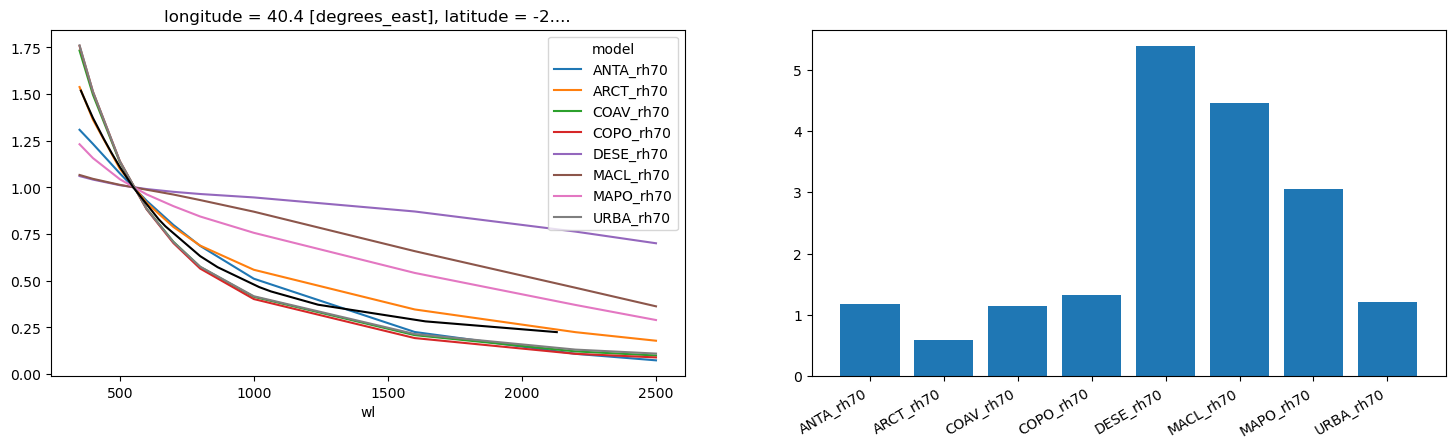

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4.5))
aero_lut.aot.sel(model=models,aot_ref=1).plot(ax=axs[0],hue='model')#,add_legend=False)
(cams_aod/cams.aod550).plot(ax=axs[0],color='black')
lut_aod=aero_lut.aot.sel(model=models,aot_ref=1).interp(wl=cams_aod.wl)
rank = np.abs((cams_aod/cams.aod550)-lut_aod).sum('wl') 
axs[1].bar(x=rank.model, height=rank.values)
plt.xticks(rotation=30, ha='right')
plt.show()

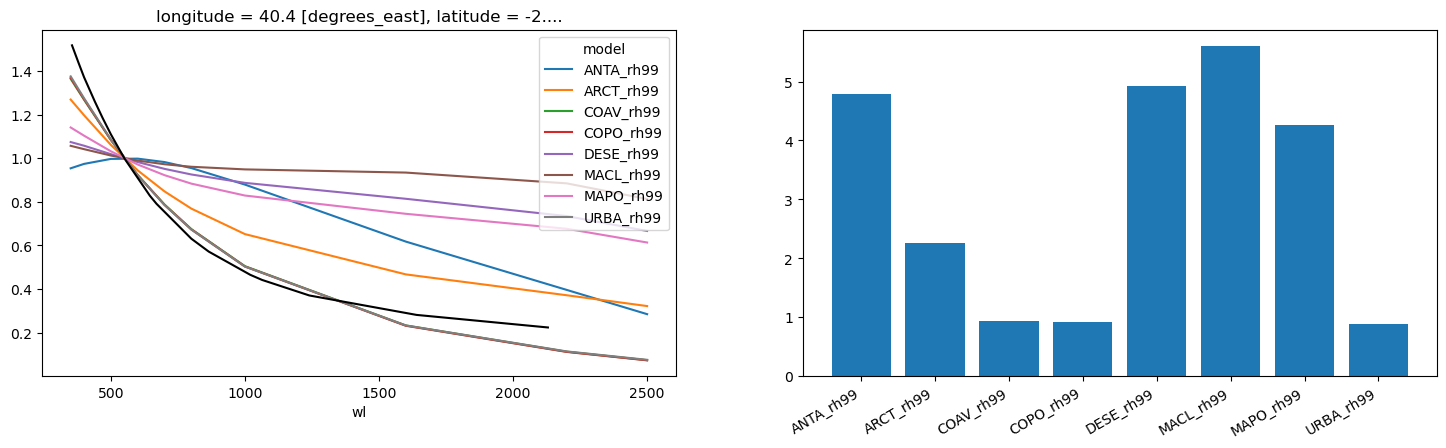

In [13]:
rh='_rh99'
models = ['ANTA'+rh,'ARCT'+rh,'COAV'+rh, 'COPO'+rh, 'DESE'+rh, 'MACL'+rh, 'MAPO'+rh, 'URBA'+rh]
fig, axs = plt.subplots(1, 2, figsize=(18, 4.5))
aero_lut.aot.sel(model=models,aot_ref=1).plot(ax=axs[0],hue='model') #,add_legend=False)
(cams_aod/cams.aod550).plot(ax=axs[0],color='black')
lut_aod=aero_lut.aot.sel(model=models,aot_ref=1).interp(wl=cams_aod.wl)
rank = np.abs((cams_aod/cams.aod550)-lut_aod).sum('wl') 
axs[1].bar(x=rank.model, height=rank.values)
plt.xticks(rotation=30, ha='right')
plt.show()

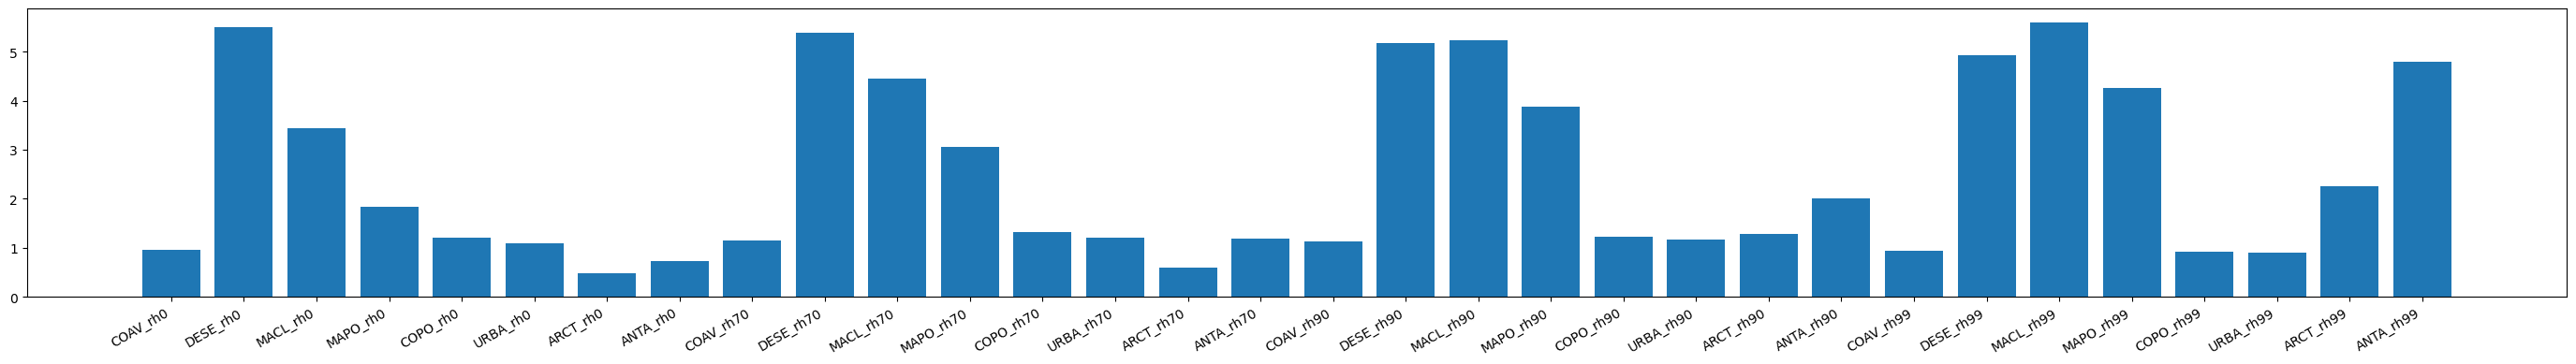

In [15]:
lut_aod=aero_lut.aot.sel(aot_ref=1).interp(wl=cams_aod.wl)
rank = np.abs((cams_aod/cams.aod550)-lut_aod).sum('wl') 
plt.figure(figsize=(35,4))
plt.bar(x=rank.model, height=rank.values)
plt.xticks(rotation=30, ha='right')
plt.show()

In [10]:
aero_lut

<xarray.Dataset>
Dimensions:            (wl: 10, model: 32, aot_ref: 9, z: 2, sza: 9, vza: 61,
                        azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * z                  (z) float32 0.0 3e+05
  * sza                (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 86.27 87.76 89.25
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
  * model              (model) object 'COAV_rh0' 'DESE_rh0' ... 'ANTA_rh99'
Data variables: (12/20)
    wl_ref             (model, wl, aot_ref) float32 ...
    Cext_ref           (model, wl, aot_ref) float32 ...
    ssa_ref            (model, wl, aot_ref) float32 ...
    aot                (model, wl, aot_ref) float32 ...
    Cext               (model, wl, aot_ref) float32 ...
    ssa                (model, wl, aot_ref) float32 ...
    ...                 ...
    Eddir              (model, aot_ref, wl, z, sza) float32 ...
    Eudir              (model, aot_ref, wl, z, sza) float32 ...
    Eodir              (model, aot_ref, wl, z, sza) float32 ...
    I                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    Q                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    U                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...

In [21]:
aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
Tdir = transmittance_dir(aot,M,rot=rot)
Tdir

<xarray.DataArray (wl: 1000, aot_ref: 9)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * wl       (wl) float64 400.0 402.1 404.2 ... 2.496e+03 2.498e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    model    <U9 'URBA_rh70'

## check NDWI and similar indices

In [ ]:
fig,axs = plt.subplots(2,3,figsize=(28,11),sharey=True,sharex=True)
axs=axs.ravel()
wl=[550,865,1600,2200]
for i_,model_ in  enumerate(models):
    model=model_+rh
    

    Rtoa_lut = aero_lut.I.sel(model=model).drop_isel(aot_ref=[0,4,6,8]).sel(sza=sza,vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))
  
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')
    
    aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])
    
    Rsim = ( sunglint_toa+Rtoa_lut)
    
    
    for aot_ref in Rtoa_lut.aot_ref.values[1:]:
        Rtoa_lut.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=axs[i_])
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axs[i_])
    #Rtoa_sim= Rsim.interp(aot_ref=0.4)
    #Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')

In [29]:
Rtoa_lut = aero_lut.I.isel(sza=slice(1,9)).sel(vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))  
Rtoa_lut.isel(wl=2)#.interp(wl=wl,method='quadratic')

<xarray.DataArray 'I' (model: 32, aot_ref: 9, sza: 8)>
array([[[0.07594077, 0.07266093, 0.06744726, ..., 0.05016746,
         0.04546707, 0.03575967],
        [0.07734447, 0.07382196, 0.06869928, ..., 0.0509879 ,
         0.04614002, 0.03603316],
        [0.09055009, 0.08498763, 0.07841007, ..., 0.05881121,
         0.05238169, 0.03857896],
        ...,
        [0.14903834, 0.13966814, 0.12883326, ..., 0.09614938,
         0.07699592, 0.04598284],
        [0.16788973, 0.15865007, 0.14835562, ..., 0.10723046,
         0.08287992, 0.04750508],
        [0.19151108, 0.18248028, 0.17072377, ..., 0.11886634,
         0.08856745, 0.04904794]],

       [[0.07594572, 0.07262751, 0.06740706, ..., 0.05013091,
         0.04543509, 0.03574375],
        [0.0773617 , 0.0734631 , 0.06826131, ..., 0.05060908,
         0.04581   , 0.03586581],
        [0.09030925, 0.0814843 , 0.07418773, ..., 0.05521847,
         0.04937129, 0.03710438],
...
        [0.15201207, 0.13506919, 0.11951278, ..., 0.09049644,
         0.07542892, 0.04629758],
        [0.16993402, 0.15485525, 0.1413247 , ..., 0.10622582,
         0.08527325, 0.049338  ],
        [0.19761908, 0.18635081, 0.17300564, ..., 0.12953256,
         0.09885106, 0.05372769]],

       [[0.07600787, 0.07266915, 0.06743173, ..., 0.05012881,
         0.04543705, 0.03574962],
        [0.07796832, 0.07386712, 0.06850517, ..., 0.05058205,
         0.04582436, 0.0359192 ],
        [0.09606636, 0.08537325, 0.07660835, ..., 0.05513805,
         0.04962676, 0.03758959],
        ...,
        [0.168891  , 0.14306481, 0.12382989, ..., 0.0865083 ,
         0.07286366, 0.04594055],
        [0.19106854, 0.1657345 , 0.14737396, ..., 0.10211496,
         0.08301058, 0.04921125],
        [0.22350791, 0.20124158, 0.18203384, ..., 0.1268211 ,
         0.09796337, 0.05417179]]], dtype=float32)
Coordinates:
    wl       float32 500.0
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    z        float32 3e+05
    vza      float32 10.09
    azi      float32 90.0
  * sza      (sza) float32 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * model    (model) object 'COAV_rh0' 'DESE_rh0' ... 'ARCT_rh99' 'ANTA_rh99'

In [18]:
aero_lut.I.drop_isel(aot_ref=[0,4,6,8]).sel(model=model)

SyntaxError: positional argument follows keyword argument (1658192731.py, line 1)